In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Abre el archivo en modo lectura binaria ('rb')
with open('../data/bank_26.pkl', 'rb') as archivo:
    df = pickle.load(archivo)
    # print(datos)

/tmp/ipykernel_7868/3770387418.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(archivo)


In [5]:
df['job'].value_counts()

job
management       2520
blue-collar      1917
technician       1791
admin.           1317
services          916
retired           774
self-employed     399
student           359
unemployed        347
entrepreneur      322
housemaid         270
unknown            68
Name: count, dtype: int64

In [7]:
datos.head(n=5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [9]:
datos.info()

<class 'pandas.DataFrame'>
Index: 11000 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11000 non-null  int64 
 1   job        11000 non-null  object
 2   marital    11000 non-null  object
 3   education  10634 non-null  object
 4   default    11000 non-null  object
 5   balance    11000 non-null  int64 
 6   housing    11000 non-null  object
 7   loan       11000 non-null  object
 8   contact    11000 non-null  object
 9   day        11000 non-null  int64 
 10  month      11000 non-null  object
 11  duration   11000 non-null  int64 
 12  campaign   11000 non-null  int64 
 13  pdays      11000 non-null  int64 
 14  previous   11000 non-null  int64 
 15  poutcome   11000 non-null  object
 16  deposit    11000 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.5+ MB


In [10]:
# Comprobamos si hay valores nulos
datos.isnull().sum()

age            0
job            0
marital        0
education    366
default        0
balance        0
housing        0
loan           0
contact        0
day            0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
deposit        0
dtype: int64

In [64]:
datos.nunique() / datos.shape[0] * 100

age           0.690909
job           0.109091
marital       0.027273
education     0.036364
default       0.018182
balance      34.390909
housing       0.018182
loan          0.018182
contact       0.027273
day           0.281818
month         0.109091
duration     12.936364
campaign      0.327273
pdays         4.290909
previous      0.309091
poutcome      0.036364
deposit       0.018182
dtype: float64

In [26]:
# Comprobamos si el dataset está desbalanceado
datos['deposit'].value_counts()

deposit
no     5780
yes    5220
Name: count, dtype: int64

In [27]:
datos['pdays'].value_counts()

pdays
-1      8203
 92      105
 182      88
 91       82
 181      79
        ... 
 651       1
 214       1
 24        1
 701       1
 118       1
Name: count, Length: 472, dtype: int64

### Análisis Univariante

<Axes: xlabel='pdays', ylabel='Count'>

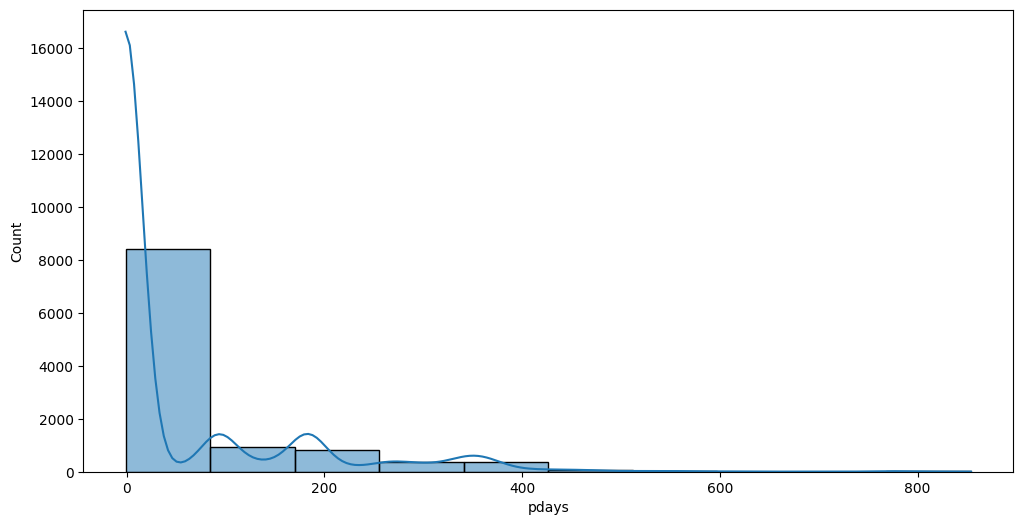

In [31]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=datos,
    x='pdays',
    bins=10,
    kde=True
)

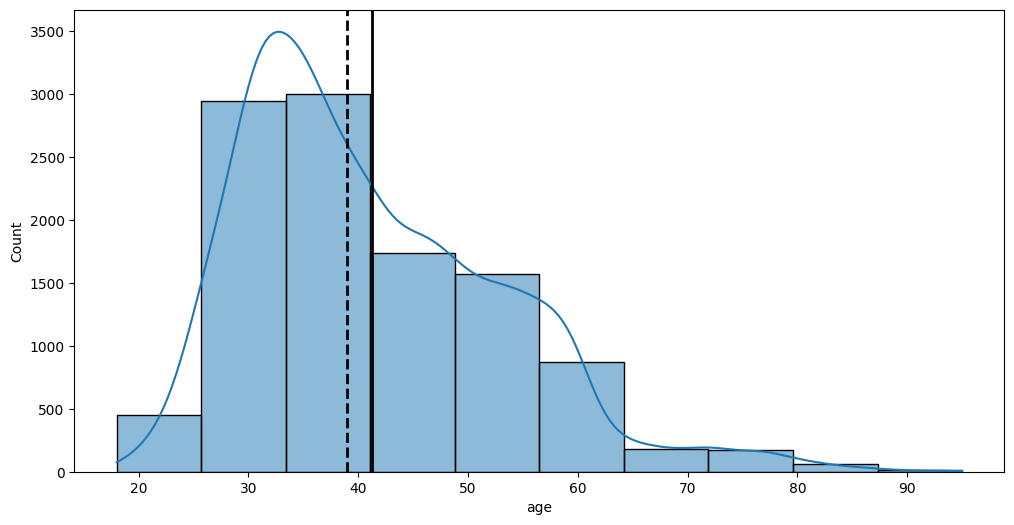

In [37]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=datos,
    x='age',
    bins=10,
    kde=True
)
plt.axvline(x=datos['age'].mean(), color="black", linewidth=2.0)
plt.axvline(x=datos['age'].median(), color="black", linestyle="--", linewidth=2.0)

Text(0.5, 1.0, 'Distribución de Balance (percentiles 1-99)')

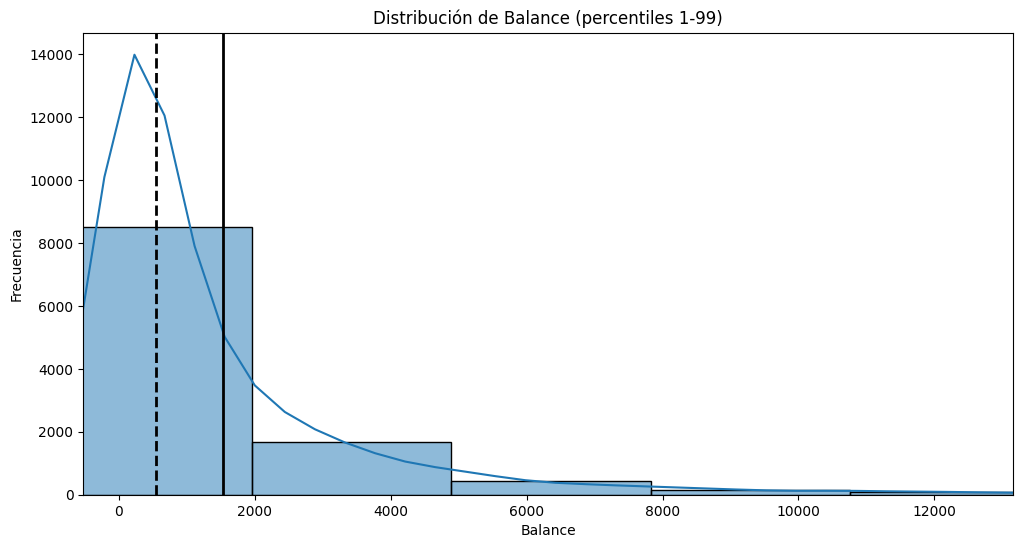

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=datos,
    x='balance',
    bins=30,
    kde=True
)
plt.axvline(x=datos['balance'].mean(), color="black", linewidth=2.0)
plt.axvline(x=datos['balance'].median(), color="black", linestyle="--", linewidth=2.0)

# Ajustar la escala para mejor visualización
plt.xlim(datos['balance'].quantile(0.01), datos['balance'].quantile(0.99))
plt.xlabel('Balance')
plt.ylabel('Frecuencia')
plt.title('Distribución de Balance (percentiles 1-99)')

<Axes: xlabel='job', ylabel='count'>

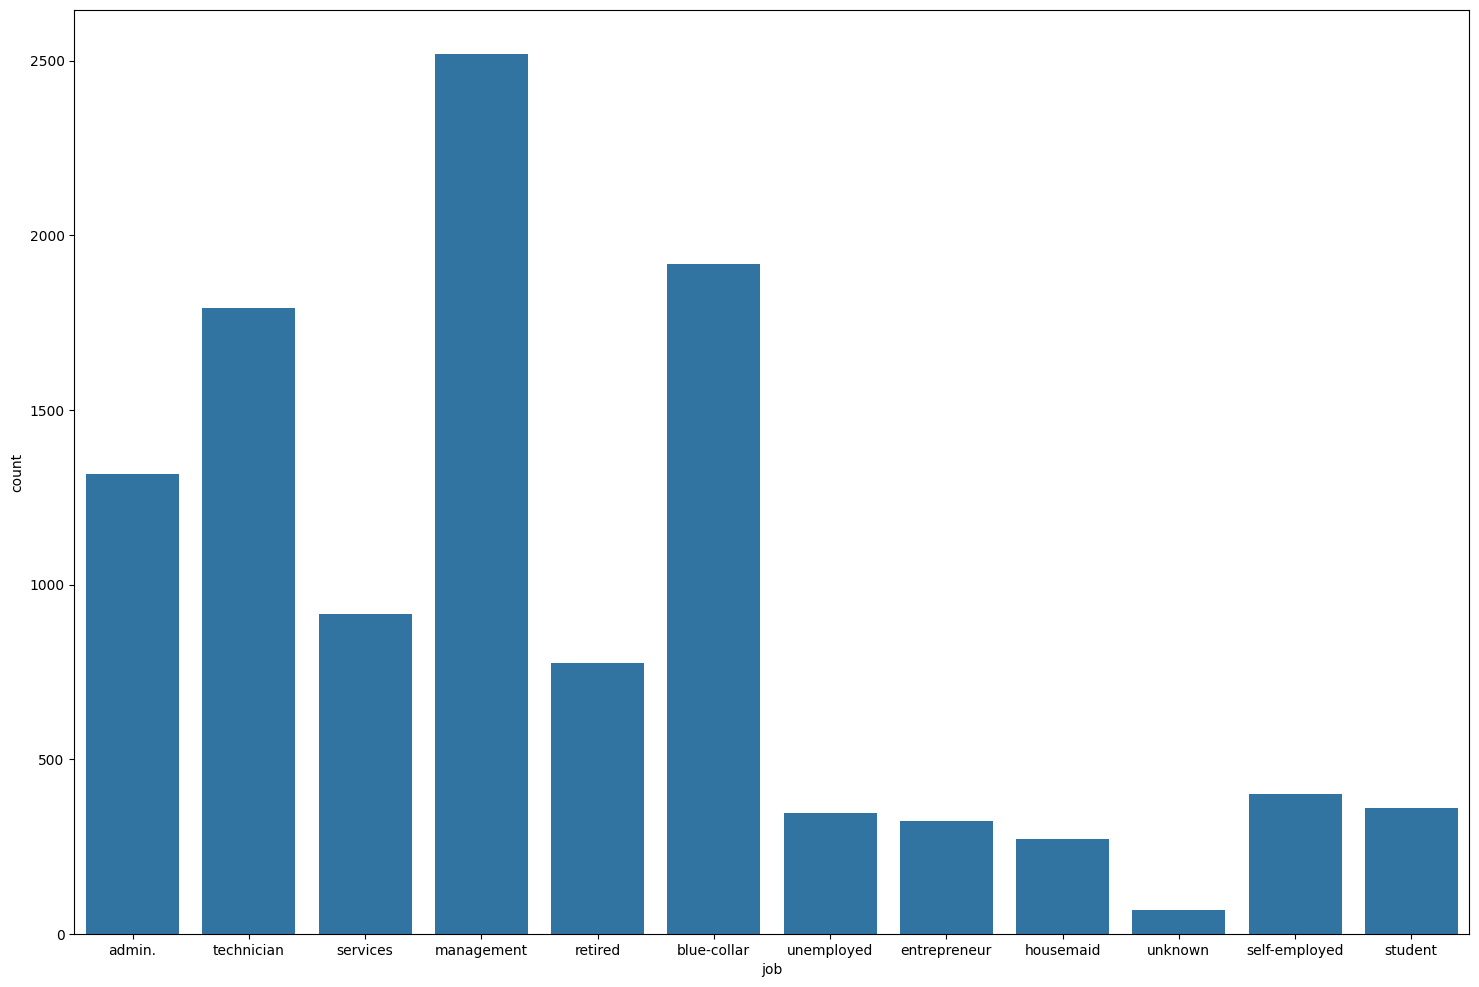

In [50]:
plt.figure(figsize=(18, 12))
sns.countplot(
    data=datos,
    x='job'
)

<Figure size 1200x600 with 0 Axes>

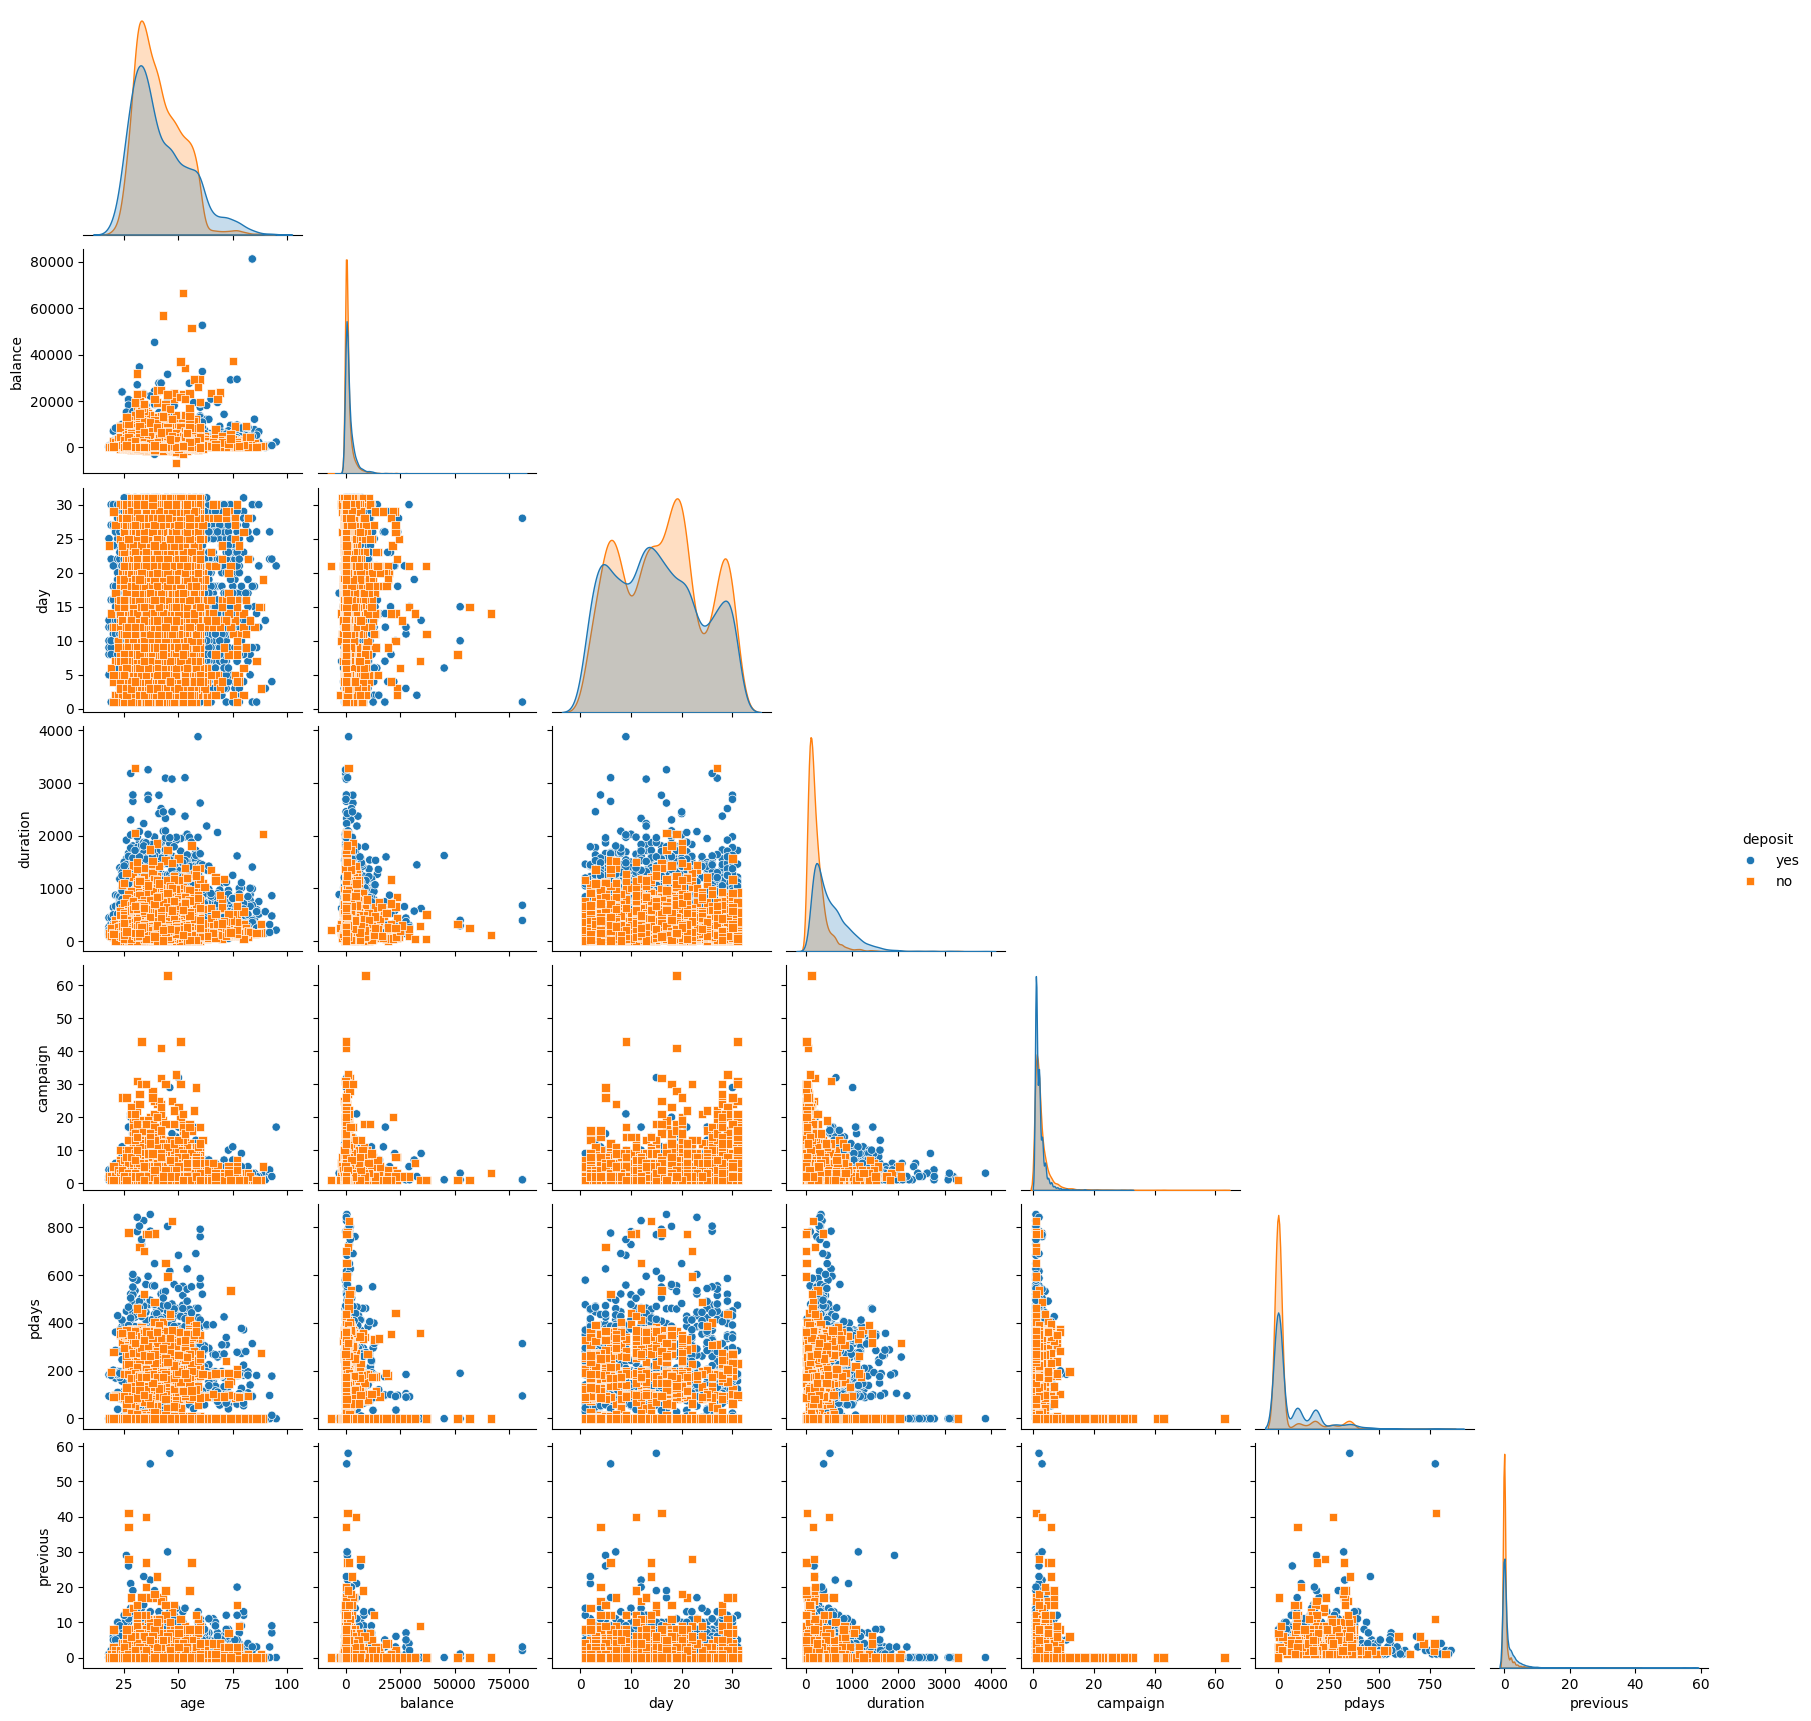

In [54]:
plt.figure(figsize=(12, 6))
sns.pairplot(
    datos,
    hue='deposit',
    markers=["o", "s"],
    corner="yes"
)

<Axes: xlabel='pdays', ylabel='Count'>

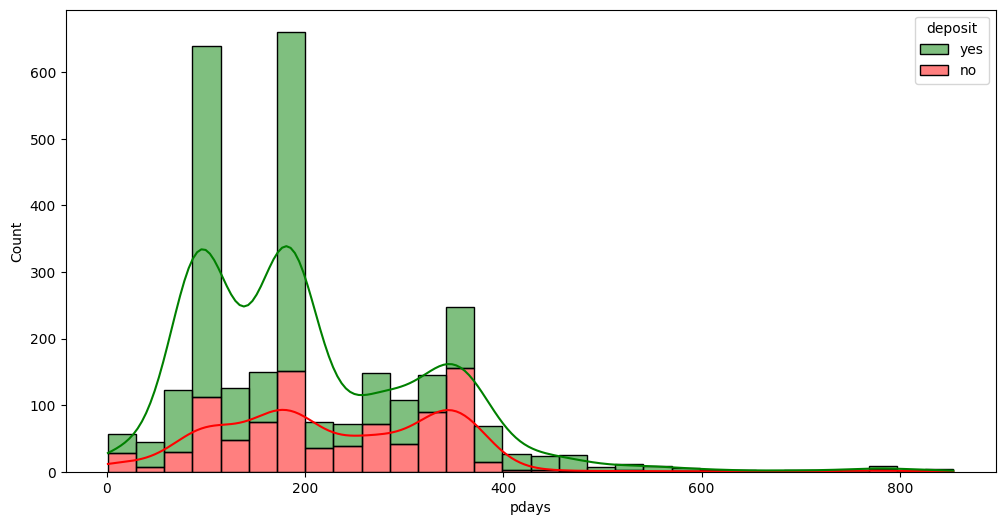

In [70]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=datos[datos['pdays'] != -1],
    x='pdays',
    bins=30,
    kde=True,
    hue="deposit",
    multiple='stack',
    palette={'yes': 'green', 'no': 'red'}
)

In [67]:
(datos['pdays'] == -1).value_counts()

pdays
True     8203
False    2797
Name: count, dtype: int64

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >, <Axes: >]],
      dtype=object)

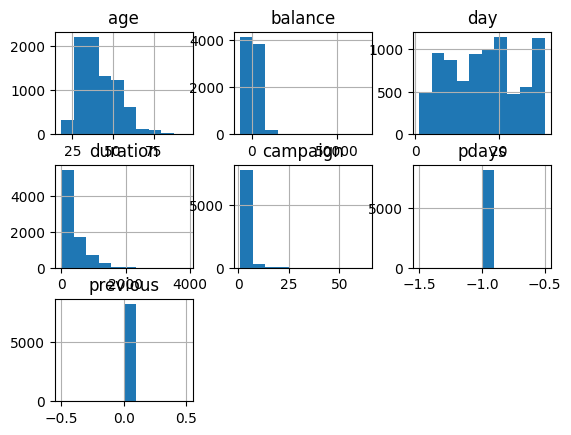

In [80]:
# Definimos una máscara
not_previous_contact = datos[datos['pdays'] == -1]
not_previous_contact.hist()